# Logistic Regression training and testing

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

## Load Titanic dataset



In [75]:
import seaborn as sns

df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


What we want to predict: survival rate

In [76]:
y = df["survived"]

In [77]:
y[:4]

0    0
1    1
2    1
3    1
Name: survived, dtype: int64

In [78]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

X = df[features]

y = df["survived"]

X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


The dataset has missing values.. so we need to fill them in with something.

In [79]:
X = X.copy()

X["age"] = X["age"].fillna(X["age"].median())
X["fare"] = X["fare"].fillna(X["fare"].median())
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])

X.isna().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Do you remember why we need to separate in train/test data?

Answer: so that we don't use the same data that we have used to train the model (which makes it predicts everything correctly). New test data helps us evaluate the model.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (712, 7)
Test size: (179, 7)


In [81]:
# numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
numeric_features = ["age"]
categorical_features = ["sex", "embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [82]:
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [83]:
y_pred = log_reg.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [84]:
y_proba = log_reg.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.17162953, 0.14924305, 0.32777824, 0.15244057, 0.72230161,
       0.68075438, 0.68075438, 0.14818956, 0.2803091 , 0.16011989])

In [85]:
results = pd.DataFrame({
    "true_survived": y_test.values,
    "predicted_class": y_pred,
    "predicted_probability_survival": y_proba
})

results.head(10)

,true_survived,predicted_class,predicted_probability_survival
0,0,0,0.171630
1,0,0,0.149243
2,1,0,0.327778
3,0,0,0.152441
4,1,1,0.722302
5,1,1,0.680754
6,1,1,0.680754
7,0,0,0.148190
8,0,0,0.280309
9,0,0,0.160120


In [86]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")


Accuracy:  0.777
Precision: 0.738
Recall:    0.652
F1-score:  0.692


Accuracy = how often the model is correct

Precision = when the model predicts survived, how often is it right?

Recall = among people who survived, how many did the model find?

F1 = balance between precision and recall

In [87]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did not survive", "Survived"]
))

                 precision    recall  f1-score   support

Did not survive       0.80      0.85      0.82       110
       Survived       0.74      0.65      0.69        69

       accuracy                           0.78       179
      macro avg       0.77      0.75      0.76       179
   weighted avg       0.77      0.78      0.77       179



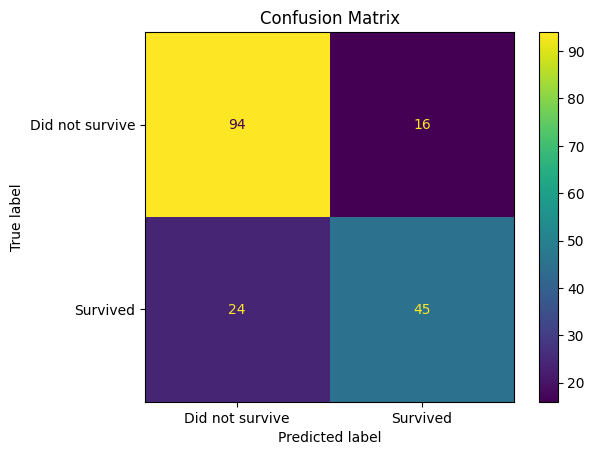

In [88]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not survive", "Survived"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

1. What is the target variable?
    - Target variable: survived. The model is trying to predict the survival rate of passengers.
2. Which features are numerical?
    - age
3. Which features are categorical?
    - sex, embarked
4. Why do we use OneHotEncoder?
    - The model must operates on number, not strings. OneHotEncoder creates a new binary column for each unique category in a feature, so that the model can process.
5. Why do we scale numerical features?
    - Without scaling, a feature like Age (0–80) would have a much larger impact than SibSp (0–8) simply because the numbers are bigger. Scaling puts fairness for these features.
6. What does accuracy measure?
   - The percenrage of predictions that are correct
7. What does precision measure?
   - Of all the people the model predicted would survive, how many actually did
8. What does recall measure?
    - Of all the people who actually survived, how many did the model correctly identify
9. In the Titanic case, is recall important? Why?
    - Recall can be important if the model wants to predict correctly the number of survivors for sending rescue boats. A better recall might saves more lives because less people are left behind.
10. Look at the coefficients. Which features increase the probability of survival?
    - being younger (coeff of "age" is negative), "sex" (female) and "embarked" (C)
11. Which features decrease the probability of survival?
    - "sex" (male), "embarked" (Q, S) and being older (coeff "age" is negative)
12. Try removing features. How do the metrics change?
    - Removing age: no significant changes
    - Removing embarked: no significant changes
    - Removing sex: Precision decreased to 0.480, Accuracy decreased to 0.609, Recall and F1 score significantly decreased (0.174 and 0.255)

In [89]:
#10-Look at the coefficients. Which features increase the probability of survival?
classifier = log_reg.named_steps["classifier"]

features = log_reg.named_steps["preprocessor"].get_feature_names_out()

import pandas as pd
coef_series = pd.Series(classifier.coef_[0], index=features)

print("Coefficients:\n", coef_series.sort_values(ascending=False))
print("\nIntercept:", classifier.intercept_)

Coefficients:
 num__age          -0.108390
cat__embarked_Q   -0.707133
cat__embarked_S   -0.839228
cat__sex_male     -2.431220
dtype: float64

Intercept: [1.65089235]


13. Try changing the decision threshold from 0.5 to 0.3. What happens to precision and recall?

In [90]:
threshold = 0.3

y_pred_threshold = (y_proba >= threshold).astype(int)

print(f"Metrics with threshold = {threshold}")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_threshold):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_threshold):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_threshold):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_threshold):.3f}")

Metrics with threshold = 0.3
Accuracy:  0.743
Precision: 0.649
Recall:    0.725
F1-score:  0.685


In [92]:
# Recall increased and Precision decreased. Model is now identifying actual survivors more correctly,
# but becoming less correct to guess if a passenger survived or not.

Let's plot the decision lines

In [93]:
# Get the trained logistic regression classifier from the pipeline
classifier = log_reg.named_steps["classifier"]

# Transform X_test using the fitted preprocessor
X_test_transformed = log_reg.named_steps["preprocessor"].transform(X_test)

# Compute the linear score z = Xw + b --> this is what decision_function does, not really used in practice
z = classifier.decision_function(X_test_transformed)

# Compute sigmoid
p_manual = 1 / (1 + np.exp(-z))

# Get probabilities from sklearn
p_sklearn = log_reg.predict_proba(X_test)[:, 1]

# Check that they are the same
print("Manual sigmoid probabilities:")
print(p_manual[:10])

print("\nSklearn probabilities:")
print(p_sklearn[:10])

Manual sigmoid probabilities:
[0.17162953 0.14924305 0.32777824 0.15244057 0.72230161 0.68075438
 0.68075438 0.14818956 0.2803091  0.16011989]

Sklearn probabilities:
[0.17162953 0.14924305 0.32777824 0.15244057 0.72230161 0.68075438
 0.68075438 0.14818956 0.2803091  0.16011989]


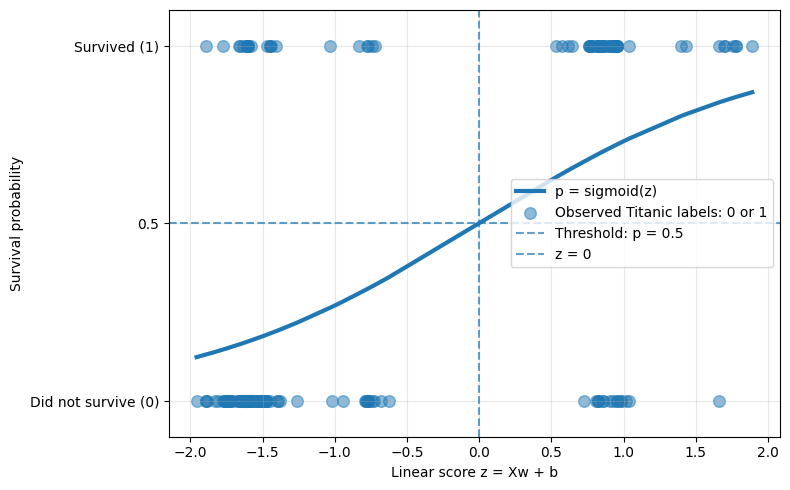

In [94]:
# Sort values so the curve is smooth
order = np.argsort(z)

z_sorted = z[order]
p_sorted = p_manual[order]

plt.figure(figsize=(8, 5))

plt.plot(
    z_sorted,
    p_sorted,
    linewidth=3,
    label="p = sigmoid(z)"
)

plt.scatter(
    z,
    y_test,
    s=70,
    alpha=0.5,
    label="Observed Titanic labels: 0 or 1"
)

plt.axhline(
    0.5,
    linestyle="--",
    alpha=0.7,
    label="Threshold: p = 0.5"
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.7,
    label="z = 0"
)

plt.xlabel("Linear score z = Xw + b")
plt.ylabel("Survival probability")

plt.yticks([0, 0.5, 1], ["Did not survive (0)", "0.5", "Survived (1)"])
plt.ylim(-0.1, 1.1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()